<a href="https://colab.research.google.com/github/vhousos/EKPA/blob/main/chousos_ids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

General Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical




Load the csv file from Mr Demertzis github repository, and analyze the available headers. Separate features/labels - MIN/MAX normalization - Define Test, Train and Validation data

In [ ]:
def loadDataset():
    filename = "https://raw.githubusercontent.com/kdemertzis/EKPA/main/Data/pcap_data.csv"
    df = pd.read_csv(filename)
    df.head()

    X = df.drop('target', axis=1).to_numpy().astype('float32')
    y = df['target'].to_numpy().astype('int32')

    # Min-Max scaling
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Test data 20%
    train_data, test_data, train_label, test_label = train_test_split(
        X_scaled, y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # Train 70%, Validation 10% (0.125 * 80% ≈ 10% συνολικά)
    train_data, val_data, train_label, val_label = train_test_split(
        train_data, train_label,
        test_size=0.125,
        stratify=train_label,
        random_state=42
    )

    return (
        train_data.astype('float32'),
        train_label.astype('int32'),
        val_data.astype('float32'),
        val_label.astype('int32'),
        test_data.astype('float32'),
        test_label.astype('int32')
    )

Define the Dense Model - Load Data

In [ ]:
from sklearn.model_selection import train_test_split

def build_dense_model(input_dim, n_classes=3, lr=1e-3):
    """
    Δημιουργεί ένα απλό Dense νευρωνικό δίκτυο για ταξινόμηση 3 κλάσεων.
    """
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


train_data, train_labelp, val_data, val_labelp, test_data, test_labelp = loadDataset()

Transform to one-hot  - Class balancing weghts - Callbacks

In [ ]:
from sklearn.preprocessing import StandardScaler

nclass = 3
train_label = to_categorical(train_labelp, nclass)
val_label   = to_categorical(val_labelp,   nclass)
test_label  = to_categorical(test_labelp,  nclass)

print('train_data.shape=', train_data.shape)
print('test_data.shape=',  test_data.shape)
print('val_data.shape=',   val_data.shape)

# get the number of features
inshape = train_data.shape[1]





class_weights_raw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labelp),
    y=train_labelp
)
class_weights = {i: class_weights_raw[i] for i in range(len(class_weights_raw))}
print("class_weights:", class_weights)






os.makedirs('./savemodels', exist_ok=True)

earlyStopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

modelCheckPoint = ModelCheckpoint(
    filepath='./savemodels/model_pcap_best.{epoch:03d}-{val_accuracy:.4f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

train_data.shape= (10476, 25)
test_data.shape= (2994, 25)
val_data.shape= (1497, 25)
class_weights: {0: np.float64(0.9974293059125964), 1: np.float64(0.9954389965792474), 2: np.float64(1.007210845111047)}


Create and train the model - Load the best model from "savedmodels"

In [ ]:
epochs = 100
batch_size = 256

model = build_dense_model(input_dim=inshape, n_classes=nclass, lr=1e-3)
model.summary()

history = model.fit(
    train_data, train_label,
    shuffle=True,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(val_data, val_label),
    class_weight=class_weights,
    callbacks=[modelCheckPoint, earlyStopping]
)



str_models = os.listdir('./savemodels')
str_models = np.sort(str_models)
best_model = str_models[-1]
print('best_model =', best_model)

model.load_weights('./savemodels/' + best_model)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,779 (46.01 KB)

 Trainable params: 11,779 (46.01 KB)

 Non-trainable params: 0 (0.00 B)

...

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9066 - loss: 0.3614 - val_accuracy: 0.9011 - val_loss: 0.3894
Epoch 63/100
30/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9074 - loss: 0.3520
Epoch 63: val_accuracy did not improve from 0.90114
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9074 - loss: 0.3532 - val_accuracy: 0.8991 - val_loss: 0.3884
Epoch 64/100
36/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9064 - loss: 0.3676
Epoch 64: val_accuracy did not improve from 0.90114
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9067 - loss: 0.3659 - val_accuracy: 0.8998 - val_loss: 0.3919
Epoch 65/100
37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9050 - loss: 0.3679
Epoch 65: val_accuracy improved from 0.90114 to 0.90180, saving model to ./savemodels/model_pcap_best.065-0.9018.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9053 - loss: 0.3665 - val_accuracy: 0.9018 - val_loss: 0.3916
Epoch 66/100
36/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9063 - loss: 0.3505
Epoch 66: val_accuracy did not improve from 0.90180
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9064 - loss: 0.3512 - val_accuracy: 0.8878 - val_loss: 0.3965
Epoch 67/100
37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9113 - loss: 0.3469
Epoch 67: val_accuracy did not improve from 0.90180
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9111 - loss: 0.3478 - val_accuracy: 0.9005 - val_loss: 0.3913
Epoch 68/100
36/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9076 - loss: 0.3531
Epoch 68: val_accuracy did not improve from 0.90180
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9077 - loss: 0.3530 - val_accuracy: 0.8985 - val_loss: 0.3976
Epoch 69/100
37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9051 - loss: 0.3580
Epoch 69: val_accuracy did not improve f

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9112 - loss: 0.3414 - val_accuracy: 0.9051 - val_loss: 0.3877
Epoch 71/100
37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9072 - loss: 0.3534
Epoch 71: val_accuracy did not improve from 0.90514
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9074 - loss: 0.3527 - val_accuracy: 0.9025 - val_loss: 0.3898
Epoch 72/100
37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9092 - loss: 0.3523
Epoch 72: val_accuracy did not improve from 0.90514
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9091 - loss: 0.3521 - val_accuracy: 0.8945 - val_loss: 0.3897
Epoch 73/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9071 - loss: 0.3593
Epoch 73: val_accuracy did not improve from 0.90514
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9078 - loss: 0.3572 - val_accuracy: 0.9018 - val_loss: 0.3894
Epoch 74/100
36/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9103 - loss: 0.3468
Epoch 74: val_accuracy did not improve 

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9124 - loss: 0.3352 - val_accuracy: 0.9065 - val_loss: 0.3839
Epoch 90/100
36/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9131 - loss: 0.3374
Epoch 90: val_accuracy did not improve from 0.90648
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9130 - loss: 0.3380 - val_accuracy: 0.9005 - val_loss: 0.3867
Epoch 91/100
37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9151 - loss: 0.3276
Epoch 91: val_accuracy did not improve from 0.90648
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9145 - loss: 0.3293 - val_accuracy: 0.9025 - val_loss: 0.3893
Epoch 92/100
37/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9135 - loss: 0.3347
Epoch 92: val_accuracy improved from 0.90648 to 0.90715, saving model to ./savemodels/model_pcap_best.092-0.9071.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9134 - loss: 0.3349 - val_accuracy: 0.9071 - val_loss: 0.3842
Epoch 93/100
33/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9144 - loss: 0.3268
Epoch 93: val_accuracy did not improve from 0.90715
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9146 - loss: 0.3286 - val_accuracy: 0.9018 - val_loss: 0.3896
Epoch 94/100
36/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9147 - loss: 0.3315
Epoch 94: val_accuracy did not improve from 0.90715
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9142 - loss: 0.3324 - val_accuracy: 0.9045 - val_loss: 0.3833
Epoch 95/100
35/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9123 - loss: 0.3399
Epoch 95: val_accuracy did not improve from 0.90715
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9122 - loss: 0.3393 - val_accuracy: 0.9025 - val_loss: 0.3869
Epoch 96/100
34/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9144 - loss: 0.3402
Epoch 96: val_accuracy did not improve f

Confusion matrix to "test" set - Plotting the confusion matrix

TEST DATA - Confusion matrix:
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[879  65  57]
 [ 38 923  42]
 [ 41  21 928]]
Accuracy ratios for each class
Normal (0) = 0.8781
Anomaly (1) = 0.9202
Attack (2) = 0.9374


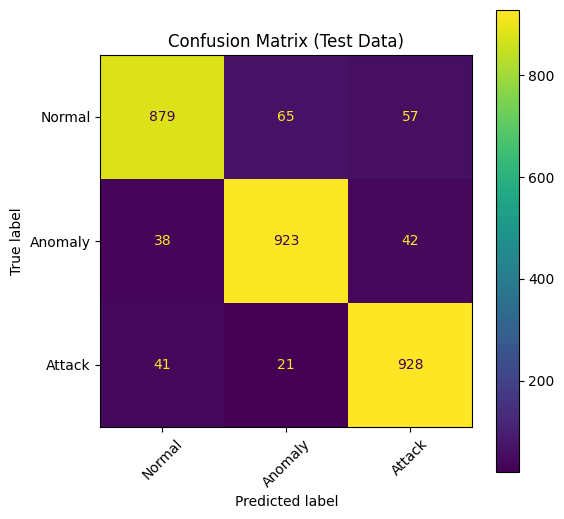

In [ ]:
print('TEST DATA - Confusion matrix:')

pred = model.predict(test_data)
pred_y = np.argmax(pred, axis=1)

cm = confusion_matrix(test_labelp.astype('int32'), pred_y)
print(cm)

print('Accuracy ratios for each class')
for i, cls_name in enumerate(['Normal (0)', 'Anomaly (1)', 'Attack (2)']):
    acc_i = cm[i, i] / np.sum(cm[i, :])
    print(f'{cls_name} = {acc_i:.4f}')





label_names = np.array(['Normal', 'Anomaly', 'Attack'])

cmo = ConfusionMatrixDisplay(cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(6, 6))
cmo.plot(ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix (Test Data)')
plt.show()

Plotting training/validation accuracy & loss

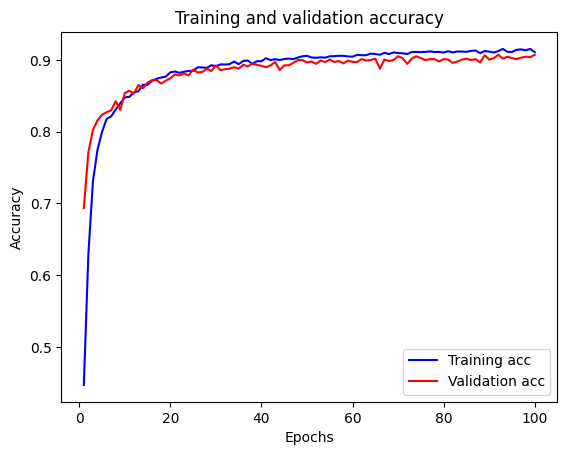

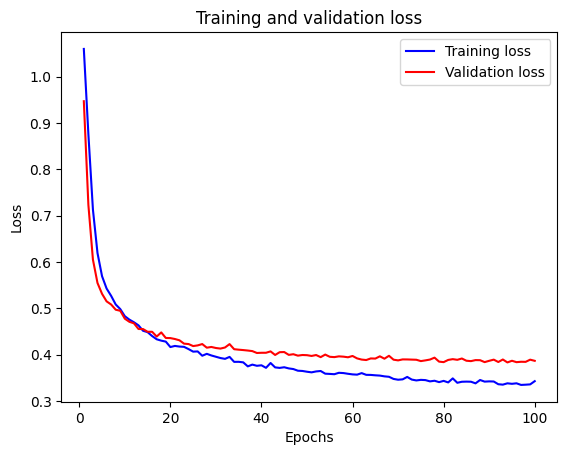

In [ ]:
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss    = history.history['loss']
val_loss= history.history['val_loss']

epochs_range = range(1, len(acc) + 1)




plt.figure()
plt.plot(epochs_range, acc,     'b', label='Training acc')
plt.plot(epochs_range, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()




plt.figure()
plt.plot(epochs_range, loss,     'b', label='Training loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()